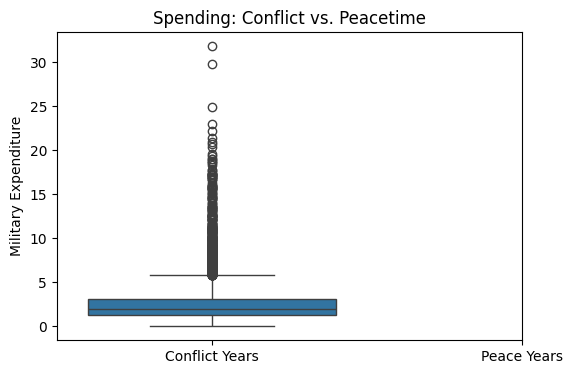

T-statistic = 8.235
P-value      = 0.000
Significant difference (p < 0.05)


In [2]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the two datasets
mil = pd.read_csv('military_expenditure.csv')
ucdp = pd.read_csv('conflict.csv', encoding='latin1')

# Renmaing the military expenditure data
mil = mil.rename(columns={
    'country': 'Country',
    'year':    'Year',
    'Military expenditure (% of GDP)':   'military_expenditure'
})

#  Build country-year conflict table
ucdp['location_list'] = ucdp['location'].str.split(',')
ucdp_expanded = ucdp.explode('location_list')
ucdp_expanded['Country'] = ucdp_expanded['location_list'].str.strip()

# Count conflicts per country-year, and sum intensity
conf_ctry_year = (
    ucdp_expanded
    .groupby(['Country', 'year'])
    .agg(
        conflict_count=('conflict_id', 'nunique'),
        total_intensity=('cumulative_intensity', 'sum')
    )
    .reset_index()
)
# Make a binary flag: 1 if any conflict, else 0
conf_ctry_year['conflict_flag'] = (conf_ctry_year['conflict_count'] > 0).astype(int)

# Merge with military expenditure data
df = pd.merge(
    mil,
    conf_ctry_year,
    left_on=['Country', 'Year'],
    right_on=['Country', 'year'],
    how='left'
)
df['conflict_flag']   = df['conflict_flag'].fillna(0).astype(int)
df['total_intensity'] = df['total_intensity'].fillna(0)

# Split into conflict vs peacetime
conflict_years = df[df['conflict_flag'] == 1]['military_expenditure']
peace_years    = df[df['conflict_flag'] == 0]['military_expenditure']

# Visual comparison
plt.figure(figsize=(6,4))
sns.boxplot(data=[conflict_years, peace_years])
plt.xticks([0,1], ['Conflict Years','Peace Years'])
plt.ylabel('Military Expenditure')
plt.title('Spending: Conflict vs. Peacetime')
plt.show()

# Two-sample t-test
t_stat, p_value = stats.ttest_ind(conflict_years.dropna(),
                                  peace_years.dropna(),
                                  equal_var=False)
print(f"T-statistic = {t_stat:.3f}")
print(f"P-value      = {p_value:.3f}")
if p_value < 0.05:
    print("Significant difference (p < 0.05)")
else:
    print("No significant difference (p ≥ 0.05)")


In [10]:
mil = pd.read_csv('military_expenditure.csv')  # replace with the exact filename
mil.columns.tolist()
mil.head()

,country,iso3c,iso2c,year,Military expenditure (current USD),Military expenditure (% of general government expenditure),Military expenditure (% of GDP),adminregion,incomeLevel
0,Afghanistan,AFG,AF,1970,2.939586e+06,NaN,1.629606,South Asia,Low income
1,Afghanistan,AFG,AF,1971,NaN,NaN,NaN,South Asia,Low income
2,Afghanistan,AFG,AF,1972,NaN,NaN,NaN,South Asia,Low income
3,Afghanistan,AFG,AF,1973,3.341272e+06,NaN,1.868910,South Asia,Low income
4,Afghanistan,AFG,AF,1974,3.581366e+06,NaN,1.610825,South Asia,Low income
